# TorchSpin — Parity with EasySpin

Each section simulates a system with torchspin and overlays the spectrum EasySpin (MATLAB) produced for
the same input.  The MATLAB outputs are the stored references used by the test suite
(`tests/data/*.mat`, generated by the scripts in `tests/`); the cosine similarity printed is the
same metric the validation tests assert on (threshold 0.995–0.999 depending on the module).

Covered here: `pepper` (rhombic S=1/2, and an S=1 triplet with zero-field splitting), `garlic`
(Fremy's salt), `chili` (slow-motion nitroxide), `saffron` (2-D HYSCORE) and `cardamom` (trajectory
EPR).  The full validation runs with `python -m pytest torchspin/tests/test_*_matlab_validation.py`.

In [1]:
# setup: use the repository checkout if torchspin is not installed
import sys
from pathlib import Path
try:
    import torchspin  # noqa: F401
except ImportError:
    _root = Path.cwd()
    while not (_root / 'torchspin').exists() and _root != _root.parent:
        _root = _root.parent
    sys.path.insert(0, str(_root))

In [2]:
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt, torch
from scipy.io import loadmat
from torchspin import SpinSystem, Experiment, Options, pepper, garlic, chili, saffron, cardamom, CardamomPar, CardamomOptions, unitconvert
from torchspin.saffron import PulseExperiment, SaffronOptions

ROOT = Path.cwd()
while not (ROOT / 'tests' / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'tests' / 'data'
ref = lambda name, **kw: loadmat(str(DATA / f'{name}.mat'), squeeze_me=True, struct_as_record=False, **kw)

def cosine(a, b):
    a = np.asarray(a, float).ravel(); b = np.asarray(b, float).ravel()
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

def overlay(ax, x, y_py, y_ml, title):
    s = np.abs(y_ml).max()
    ax.plot(x, y_ml / s, color='0.2', lw=2.2, label='EasySpin (MATLAB)')
    ax.plot(x, y_py / s, color='tab:red', lw=1.0, label='torchspin')
    ax.plot(x, (y_py - y_ml) / s - 1.3, color='tab:blue', lw=0.8, label='difference (offset)')
    cs = cosine(y_py, y_ml); print(f'{title}: cosine similarity vs EasySpin = {cs:.6f}')
    ax.set_title(f'{title}   cosine = {cs:.6f}'); ax.set_xlabel('B (mT)'); ax.legend(fontsize=8)

## 1. `pepper` — rhombic S = 1/2 powder, 1 mT Gaussian linewidth

pepper, rhombic g: cosine similarity vs EasySpin = 0.999981


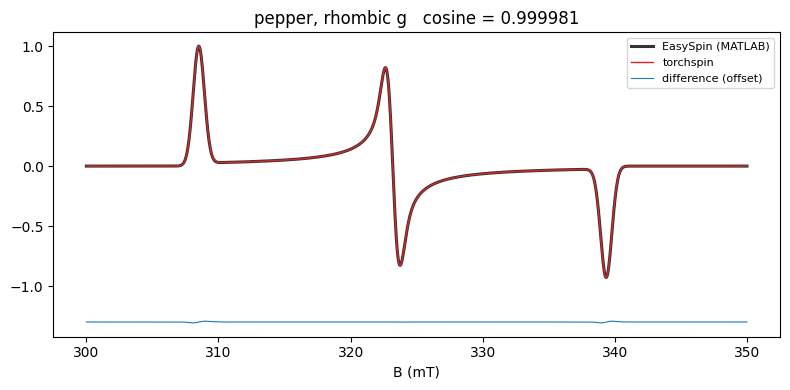

In [3]:
sys = SpinSystem(S=[0.5], g=[[2.0, 2.1, 2.2]], lw=[1.0, 0.0])
exp = Experiment(mwFreq=9.5, Range=[300, 350], nPoints=1024, Harmonic=1)
B, y = pepper(sys, exp, Options(GridSize=50, GridSymmetry='Ci', Verbosity=0))
y_ml = ref('pepper_rhombiclw')['data'].y1
fig, ax = plt.subplots(figsize=(8, 4)); overlay(ax, B.numpy(), y.numpy(), y_ml, 'pepper, rhombic g'); plt.tight_layout()

## 2. `pepper` — naphthalene triplet (S = 1, D = 0.1003 cm⁻¹, E = 0.0137 cm⁻¹), 0–500 mT

pepper, S=1 triplet: cosine similarity vs EasySpin = 0.999973


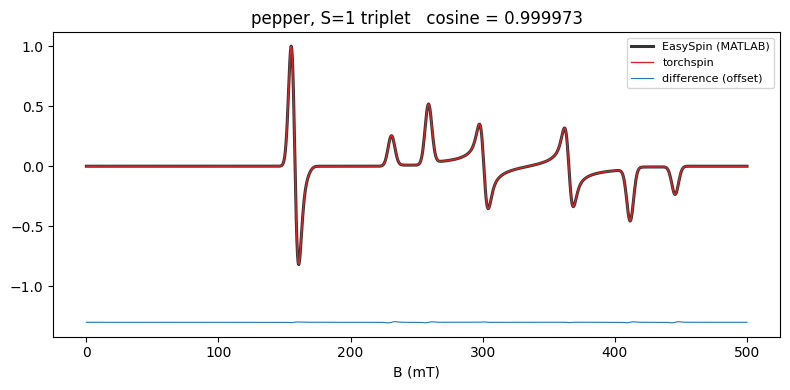

In [4]:
CM1 = 29979.2458
D, E = 0.1003 * CM1, 0.0137 * CM1
sys = SpinSystem(S=[1.0], g=[[2.003, 2.003, 2.003]], D=[[-D / 3 + E, -D / 3 - E, 2 * D / 3]], lw=[6.0, 0.0])
exp = Experiment(mwFreq=9.5, Range=[0, 500], nPoints=1024, Harmonic=1)
B, y = pepper(sys, exp, Options(GridSize=50, GridSymmetry='Ci', Verbosity=0))
y_ml = ref('example_triplet_naphthalene')['y_naph']
fig, ax = plt.subplots(figsize=(8, 4)); overlay(ax, B.numpy(), y.numpy(), y_ml, 'pepper, S=1 triplet'); plt.tight_layout()

## 3. `garlic` — Fremy's salt in solution (g = 2.0055, A(¹⁴N) = 13.09 G)

garlic, Fremy's salt: cosine similarity vs EasySpin = 0.997922


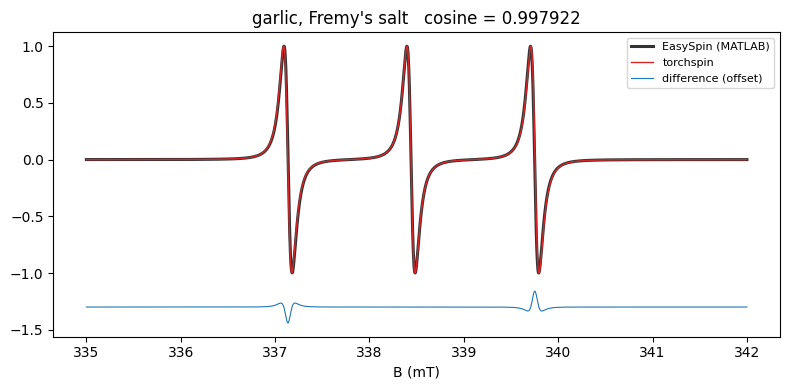

In [5]:
A_MHz = float(unitconvert(np.array([1.309]), 'mT->MHz', g=2.0055)[0])
sys = SpinSystem(S=[0.5], g=[[2.0055] * 3], Nucs=['14N'], A=[[A_MHz] * 3], lw=[0.0, 0.15])
exp = Experiment(mwFreq=9.5, Range=[335, 342], nPoints=2048, Harmonic=1)
B, y = garlic(sys, exp)
y_ml = ref('example_fremysalt')['y_fremy']
fig, ax = plt.subplots(figsize=(8, 4)); overlay(ax, np.asarray(B), np.asarray(y), y_ml, "garlic, Fremy's salt"); plt.tight_layout()

## 4. `chili` — slow-motion nitroxide (τc = 3 ns), stochastic Liouville equation

chili, nitroxide τc = 3 ns: cosine similarity vs EasySpin = 1.000000


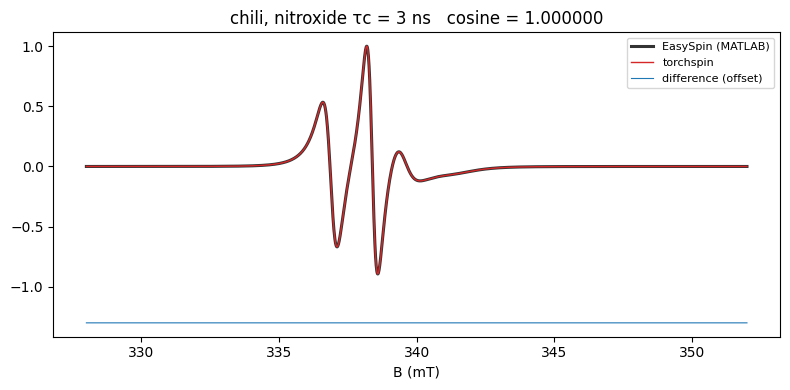

In [6]:
sys = SpinSystem(S=[0.5], g=[[2.0089, 2.0058, 2.0021]], Nucs=['14N'], A=[[16.0, 16.0, 100.0]], tcorr=3e-9, lw=[0.0, 0.05])
exp = Experiment(mwFreq=9.5, Range=[328, 352], nPoints=2048, Harmonic=1)
B, y = chili(sys, exp)
y_ml = ref('example_nitroxide_basic')['y_basic']
fig, ax = plt.subplots(figsize=(8, 4)); overlay(ax, np.asarray(B), np.asarray(y), y_ml, 'chili, nitroxide τc = 3 ns'); plt.tight_layout()

## 5. `saffron` — HYSCORE of a ¹H (A = [3, 3, 9] MHz), time domain 256 × 256

cosine (2-D time domain): 0.999996


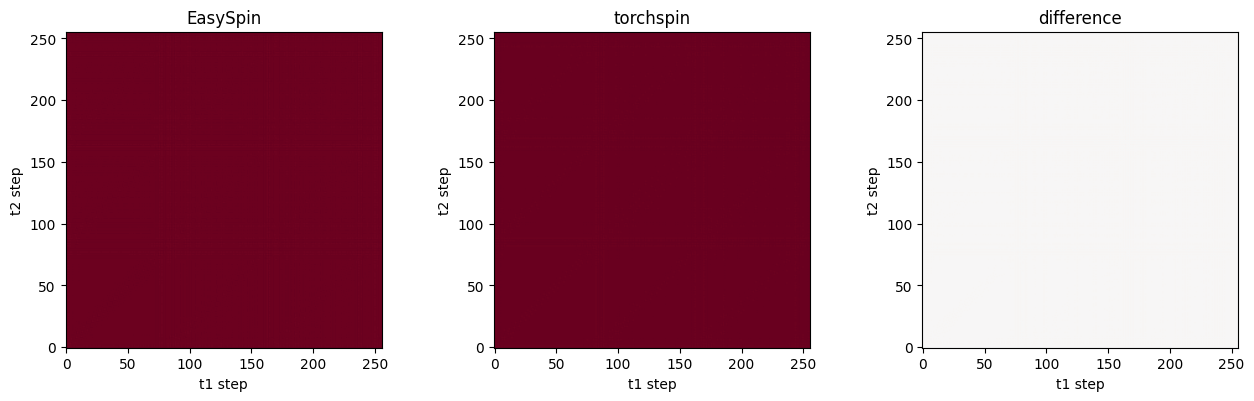

In [7]:
sys = SpinSystem(S=[0.5], g=[[2.0023] * 3], Nucs='1H', A=[[3.0, 3.0, 9.0]])
exp = PulseExperiment(Sequence='HYSCORE', Field=324.9, dt=0.050, nPoints=[256, 256], tau=0.08)
_, y, _ = saffron(sys, exp, SaffronOptions(GridSize=20, TimeDomain=True))
y = np.asarray(y); y_ml = np.asarray(ref('saffron_HYSCORE')['data'].y1)
print('cosine (2-D time domain):', round(cosine(np.real(y), np.real(y_ml)), 6))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, z, t in zip(axes, [np.real(y_ml), np.real(y), np.real(y) - np.real(y_ml)], ['EasySpin', 'torchspin', 'difference']):
    im = ax.imshow(z, origin='lower', cmap='RdBu_r', vmin=-np.abs(y_ml).max(), vmax=np.abs(y_ml).max()); ax.set_title(t); ax.set_xlabel('t1 step'); ax.set_ylabel('t2 step')
plt.tight_layout()

## 6. `cardamom` — trajectory EPR (diffusion model, fast method)

Stochastic simulation: both codes draw their own trajectories, so the agreement is statistical (the test asserts cosine > 0.75 at 100 trajectories; more trajectories converge further).

cardamom, diffusion/fast (stochastic): cosine similarity vs EasySpin = 0.999789


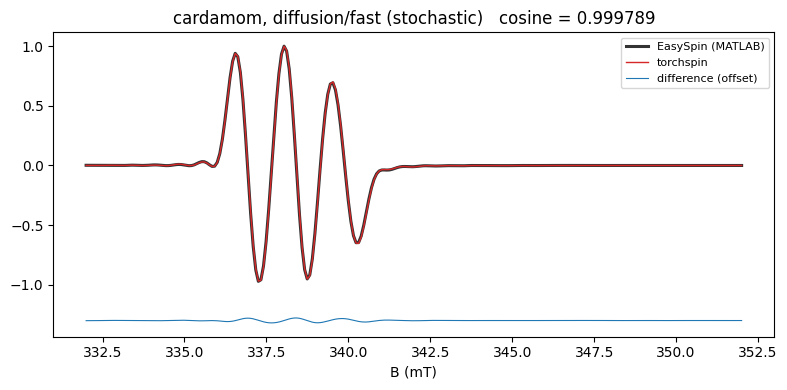

In [8]:
sys = SpinSystem(S=[0.5], g=[[2.008, 2.006, 2.003]], Nucs='14N', A=[[20.0, 20.0, 85.0]], tcorr=1e-9)
exp = Experiment(mwFreq=9.5, Range=[332, 352], nPoints=256, Harmonic=0)
par = CardamomPar(Model='diffusion', nTraj=100, nSteps=500, dtSpin=1e-10, dtSpatial=1e-10)
B, y, _, _ = cardamom(sys, exp, par, CardamomOptions(Method='fast', Verbosity=0))
r = ref('cardamom_matlab_diffusion_fast')
fig, ax = plt.subplots(figsize=(8, 4)); overlay(ax, np.asarray(B), np.real(np.asarray(y)), np.real(r['spc']), 'cardamom, diffusion/fast (stochastic)'); plt.tight_layout()

## Summary

Deterministic simulators reproduce EasySpin to cosine ≥ 0.998 here (≥ 0.9999 for the powder and slow-motion
cases; the Fremy's salt solution spectrum differs at the 0.2 % level from EasySpin's isotropic-shift
convention); the stochastic trajectory simulation agrees within its sampling noise.  The same comparisons,
over 300+ stored cases, run in the test suite.